# AutoGluon Forecasting with Chronos-2

원본 튜토리얼: https://auto.gluon.ai/dev/tutorials/timeseries/forecasting-chronos.html

이 노트북은 AutoGluon 1.5.1 문서의 `Forecasting with Chronos-2` 페이지를 바탕으로, Chronos-2를 AutoGluon `TimeSeriesPredictor` 안에서 어떻게 활용하는지 단계별로 정리합니다.

이 노트북에서 다루는 핵심은 아래와 같습니다.

- `presets="chronos2"`로 Chronos-2를 zero-shot 방식으로 바로 사용하는 방법
- `predict()`와 `backtest_predictions()`로 예측값과 예측 구간을 확인하는 방법
- covariates가 포함된 데이터에서 Chronos-2와 Chronos-Bolt 계열을 비교하는 방법
- `feature_importance()`로 어떤 외생 변수가 도움이 되었는지 확인하는 방법
- Chronos-2를 fine-tuning해서 zero-shot 모델과 비교하는 방법

Chronos-2는 일반적인 딥러닝 시계열 모델과 달리, zero-shot 예측이 가능한 pretrained foundation model입니다. 그래서 `fit()` 단계가 길게 학습을 수행한다기보다, 데이터 형식과 예측 설정을 정리하고 모델 상태를 준비하는 성격에 더 가깝습니다.
        


## 1. 라이브러리 불러오기

이 튜토리얼에서는 `pandas`로 데이터를 읽고, `matplotlib`으로 backtest 결과를 시각화합니다. 핵심 클래스는 아래 두 가지입니다.

- `TimeSeriesDataFrame`: AutoGluon이 이해하는 시계열 전용 자료구조
- `TimeSeriesPredictor`: 예측 길이, 평가 지표, covariates 설정, 학습과 예측을 담당하는 핵심 인터페이스

Chronos-2 예제는 모두 `TimeSeriesPredictor` 기반으로 진행되므로, 이후 다른 시계열 모델과 비교할 때도 인터페이스를 거의 그대로 유지할 수 있습니다.
        


In [1]:
import matplotlib.pyplot as plt
import pandas as pd

from autogluon.timeseries import TimeSeriesDataFrame, TimeSeriesPredictor
        


/Users/munju/Documents/project/TIL-github/TIL/2026/RAPIDS/2_AutoML_study/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Chronos 계열 모델 이해하기

공식 문서 기준으로 AutoGluon은 세 가지 Chronos 계열을 지원합니다.

- `Chronos`: 원래의 Chronos T5 계열 모델
- `Chronos-Bolt`: 더 빠른 추론에 초점을 둔 계열
- `Chronos-2`: 최신 세대로, cross-learning과 covariates 지원이 강화된 모델

문서에서 특히 강조하는 점은 다음과 같습니다.

- Chronos-2는 univariate forecasting뿐 아니라 covariates forecasting도 네이티브로 지원합니다.
- 추천 preset은 `"chronos2_small"`과 `"chronos2"`입니다.
- Chronos-Bolt는 빠른 baseline 비교용으로 유용하지만, covariates를 시계열 구조까지 반영해 직접 학습하는 쪽은 Chronos-2가 더 강합니다.

아래 첫 번째 실습은 가장 단순한 zero-shot univariate forecasting부터 시작합니다.
        


## 3. Zero-shot Univariate Forecasting

문서에서는 Australian Electricity Demand subset을 예제로 사용합니다. 먼저 데이터를 `TimeSeriesDataFrame`으로 읽고, 마지막 여러 예측 구간을 평가용으로 남긴 뒤 `presets="chronos2"`로 예측기를 생성합니다.

여기서 중요한 포인트는 다음과 같습니다.

- `Chronos-2`는 pretrained model이므로 별도 데이터셋 맞춤 학습 없이도 바로 예측할 수 있습니다.
- `train_test_split(num_test_windows * prediction_length)`로 여러 backtest 창을 남겨둘 수 있습니다.
- 이 예제에서는 30분 간격 데이터에서 48 step, 즉 24시간을 예측합니다.
        


In [2]:
data = TimeSeriesDataFrame.from_path(
    "https://autogluon.s3.amazonaws.com/datasets/timeseries/australian_electricity_subset/test.csv"
)

data.head()
        


target
item_id timestamp                       
T000000 2013-03-10 00:00:00  5207.959961
        2013-03-10 00:30:00  5002.275879
        2013-03-10 01:00:00  4747.569824
        2013-03-10 01:30:00  4544.880859
        2013-03-10 02:00:00  4425.952148

In [3]:
num_test_windows = 3
prediction_length = 48

train_data, test_data = data.train_test_split(num_test_windows * prediction_length)

predictor = TimeSeriesPredictor(prediction_length=prediction_length).fit(
    train_data,
    presets="chronos2",
)
        


Sorting the dataframe index before generating the train/test split.
Beginning AutoGluon training...
AutoGluon will save models to '/Users/munju/Documents/project/TIL-github/TIL/2026/RAPIDS/2_AutoML_study/tutorial_notebooks/AutogluonModels/ag-20260407_141154'
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.11.15
Operating System:   Darwin
Platform Machine:   arm64
Platform Version:   Darwin Kernel Version 25.3.0: Wed Jan 28 20:56:42 PST 2026; root:xnu-12377.91.3~2/RELEASE_ARM64_T8142
CPU Count:          10
Pytorch Version:    2.9.1
CUDA Version:       CUDA is not available
GPU Count:          WARNING: Exception was raised when calculating GPU count (AssertionError)
Memory Avail:       2.47 GB / 16.00 GB (15.4%)
Disk Space Avail:   694.07 GB / 926.30 GB (74.9%)
Setting presets to: chronos2

Fitting with arguments:
{'enable_ensemble': True,
 'eval_metric': WQL,
 'hyperparameters': {'Chronos2': {'model_path': 'autogluon/chronos-2'}},
 'kn

## 4. 예측 결과 확인하기

`predict()`를 호출하면 평균 예측값(`mean`)과 여러 분위수(`quantiles`)가 함께 반환됩니다. 즉, Chronos-2는 점 예측 하나만 주는 것이 아니라 불확실성까지 함께 제공합니다.

공식 문서 예시에서는 기본적으로 아래 분위수들이 포함됩니다.

- `0.1, 0.2, ..., 0.9`

필요하면 `TimeSeriesPredictor(..., quantile_levels=[...])`로 분위수 레벨을 직접 바꿀 수도 있습니다.
        


In [4]:
predictions = predictor.predict(train_data)
predictions.head()
        


Model not specified in predict, will default to the model with the best validation score: Chronos2


mean          0.1          0.2  \
item_id timestamp                                                    
T000000 2015-02-26 00:00:00  5223.811523  5153.143066  5178.589844   
        2015-02-26 00:30:00  5001.890625  4940.850098  4967.337891   
        2015-02-26 01:00:00  4759.130859  4684.923828  4712.408691   
        2015-02-26 01:30:00  4560.187500  4505.168457  4523.579102   
        2015-02-26 02:00:00  4439.416992  4369.610352  4390.421387   

                                     0.3          0.4          0.5  \
item_id timestamp                                                    
T000000 2015-02-26 00:00:00  5193.953613  5210.103027  5223.811523   
        2015-02-26 00:30:00  4982.128906  4991.323242  5001.890625   
        2015-02-26 01:00:00  4729.203125  4743.587402  4759.130859   
        2015-02-26 01:30:00  4535.823242  4550.487793  4560.187500   
        2015-02-26 02:00:00  4412.242188  4428.109863  4439.416992   

                                     0.6          0.7          0.8  \
item_id timestamp                                                    
T000000 2015-02-26 00:00:00  5234.564941  5248.637695  5265.144531   
        2015-02-26 00:30:00  5012.041016  5026.311523  5047.327637   
        2015-02-26 01:00:00  4770.625977  4784.587402  4803.946289   
        2015-02-26 01:30:00  4580.131836  4591.913574  4615.944336   
        2015-02-26 02:00:00  4456.724121  4474.256836  4496.025879   

                                     0.9  
item_id timestamp                         
T000000 2015-02-26 00:00:00  5295.290527  
        2015-02-26 00:30:00  5078.305176  
        2015-02-26 01:00:00  4828.080078  
        2015-02-26 01:30:00  4636.416016  
        2015-02-26 02:00:00  4509.390625

## 5. Backtest 예측 시각화

문서에서는 Chronos-2가 거의 학습 시간을 쓰지 않는 대신, 예측 시점에 강한 foundation model 추론을 수행한다고 설명합니다. 이 특성은 `backtest_predictions()`와 `plot()`으로 여러 cutoff에서 예측을 확인할 때 특히 잘 드러납니다.

아래 셀은 문서 예제를 거의 그대로 옮긴 것입니다.

- `backtest_predictions()`로 여러 validation window의 예측을 생성하고
- 처음 두 개 시계열만 골라서 시각화하며
- 각 cutoff 위치를 회색 점선으로 표시합니다.
        


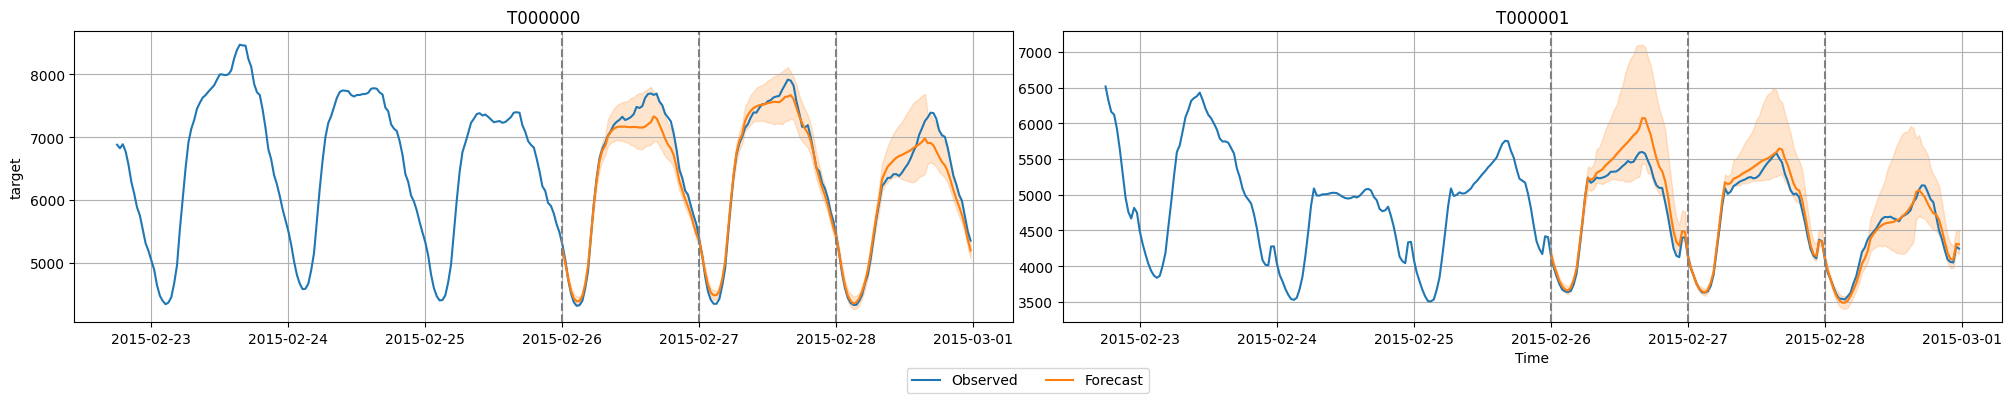

In [5]:
predictions_per_window = predictor.backtest_predictions(
    test_data,
    num_val_windows=num_test_windows,
)

item_ids = test_data.item_ids[:2].tolist()
all_predictions = pd.concat(predictions_per_window)

predictor.plot(
    test_data,
    all_predictions,
    max_history_length=300,
    item_ids=item_ids,
)

for cutoff in range(-num_test_windows * prediction_length, 0, prediction_length):
    for i, ax in enumerate(plt.gcf().axes):
        cutoff_timestamp = test_data.loc[item_ids[i]].index[cutoff]
        ax.axvline(cutoff_timestamp, color="gray", linestyle="--")

plt.show()
        


## 6. Covariates가 있는 Forecasting

이제 문서의 두 번째 핵심 예제로 넘어갑니다. 실제 업무 데이터는 target 시계열만 있는 경우보다, 날씨나 프로모션처럼 추가 정보가 함께 있는 경우가 많습니다.

Chronos-2는 다음 두 종류의 dynamic covariates를 네이티브로 지원합니다.

- `past-only covariates`: 과거 구간에서만 관측 가능한 변수
- `known future covariates`: 예측 구간의 미래 값까지 미리 제공할 수 있는 변수

문서 예제에서는 Electrical Load Forecasting 데이터에서 다음 세 개 변수를 `known_covariates`로 사용합니다.

- `airtemperature`
- `dewtemperature`
- `sealvlpressure`

실무에서는 이 값들이 실제 관측치가 아니라, 예측 시점에 확보 가능한 날씨 예보값일 수 있습니다.
        


In [6]:
covariate_data = TimeSeriesDataFrame.from_path(
    "https://autogluon.s3.amazonaws.com/datasets/timeseries/bull/test.parquet",
    id_column="id",
)

covariate_data.head()
        


load  airtemperature  \
item_id                timestamp                                     
Bull_education_Magaret 2016-01-01 00:00:00  0.0000             9.4   
                       2016-01-01 01:00:00  2.7908             8.9   
                       2016-01-01 02:00:00  3.7210             8.9   
                       2016-01-01 03:00:00  2.7908             8.3   
                       2016-01-01 04:00:00  9.3025             7.8   

                                            dewtemperature  sealvlpressure  
item_id                timestamp                                            
Bull_education_Magaret 2016-01-01 00:00:00             3.3     1028.699951  
                       2016-01-01 01:00:00             2.2     1028.800049  
                       2016-01-01 02:00:00             2.2     1029.599976  
                       2016-01-01 03:00:00             1.7     1029.500000  
                       2016-01-01 04:00:00             1.7     1029.599976

In [7]:
prediction_length = 24
train_data_cov, test_data_cov = covariate_data.train_test_split(
    prediction_length=prediction_length
)
        


Sorting the dataframe index before generating the train/test split.


## 7. Chronos-2와 Chronos-Bolt 비교하기

공식 튜토리얼은 covariates를 활용하는 `Chronos-2`와, univariate baseline 역할을 하는 `Chronos-Bolt (Small)`를 함께 비교합니다.

코드만 보면 `hyperparameters={"Chronos": {}, "Chronos2": {}}`처럼 적혀 있어서 헷갈릴 수 있는데, 문서의 실제 학습 로그에서는 `Chronos` 쪽이 `Chronos[autogluon__chronos-bolt-small]`로 해석되어 baseline 모델로 비교됩니다.

여기서 중요한 설정은 아래와 같습니다.

- `target="load"`: 예측하려는 컬럼 지정
- `known_covariates_names=[...]`: 미래에도 제공할 외생 변수 지정
- `eval_metric="MASE"`: 비교 지표를 MASE로 설정
- `enable_ensemble=False`: 비교를 단순하게 하기 위해 개별 모델만 평가

이 코드는 Chronos-2가 covariates를 활용할 수 있다는 점을 강조하기 위한 비교 실험입니다.


In [8]:
predictor_cov = TimeSeriesPredictor(
    prediction_length=prediction_length,
    target="load",
    known_covariates_names=[
        "airtemperature",
        "dewtemperature",
        "sealvlpressure",
    ],
    eval_metric="MASE",
).fit(
    train_data_cov,
    hyperparameters={"Chronos": {}, "Chronos2": {}},
    enable_ensemble=False,
    time_limit=60,
)
        


Beginning AutoGluon training... Time limit = 60s
AutoGluon will save models to '/Users/munju/Documents/project/TIL-github/TIL/2026/RAPIDS/2_AutoML_study/tutorial_notebooks/AutogluonModels/ag-20260407_141251'
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.11.15
Operating System:   Darwin
Platform Machine:   arm64
Platform Version:   Darwin Kernel Version 25.3.0: Wed Jan 28 20:56:42 PST 2026; root:xnu-12377.91.3~2/RELEASE_ARM64_T8142
CPU Count:          10
Pytorch Version:    2.9.1
CUDA Version:       CUDA is not available
GPU Count:          WARNING: Exception was raised when calculating GPU count (AssertionError)
Memory Avail:       2.62 GB / 16.00 GB (16.4%)
Disk Space Avail:   693.63 GB / 926.30 GB (74.9%)

Fitting with arguments:
{'enable_ensemble': False,
 'eval_metric': MASE,
 'hyperparameters': {'Chronos': {}, 'Chronos2': {}},
 'known_covariates_names': ['airtemperature',
                            'dewtemperature',
          

## 8. Leaderboard와 Feature Importance

문서의 핵심 관찰은 다음과 같습니다.

- test set 기준 `Chronos-2`가 `Chronos-Bolt`보다 더 좋은 MASE를 기록했습니다.
- 특히 covariates를 함께 사용했기 때문에, Chronos-2가 단순 univariate baseline보다 더 풍부한 신호를 활용할 수 있었습니다.

또한 `feature_importance()`를 이용하면 어떤 외생 변수가 성능 향상에 더 크게 기여했는지도 볼 수 있습니다. 문서 예시에서는 `airtemperature`의 중요도가 가장 높게 나타났습니다.
        


In [9]:
leaderboard_cov = predictor_cov.leaderboard(test_data_cov)
leaderboard_cov
        


Additional data provided, testing on additional data. Resulting leaderboard will be sorted according to test score (`score_test`).


,model,score_test,score_val,pred_time_test,pred_time_val,fit_time_marginal,fit_order
0,Chronos2,-0.696239,-0.817203,23.087009,28.640633,1.037675,1
1,Chronos[autogluon__chronos-bolt-small],-1.278404,-1.086471,1.226236,1.655931,0.433455,2


In [10]:
feature_importance = predictor_cov.feature_importance(
    test_data_cov,
    model="Chronos2",
    relative_scores=True,
)
feature_importance
        


Computing feature importance


,importance,stdev,n,p99_low,p99_high
airtemperature,0.324309,0.0,5.0,0.324309,0.324309
dewtemperature,0.057110,0.0,5.0,0.057110,0.057110
sealvlpressure,0.038278,0.0,5.0,0.038278,0.038278


## 9. Chronos-2 Fine-tuning

문서의 마지막 핵심은 fine-tuning입니다. AutoGluon에서는 zero-shot Chronos-2와 fine-tuned Chronos-2를 같은 `TimeSeriesPredictor` 안에 함께 넣고 비교할 수 있습니다.

이 예제에서는 아래 두 설정을 동시에 학습합니다.

- `Chronos2ZeroShot`: pretrained 모델을 그대로 사용
- `Chronos2FineTuned`: 같은 pretrained 모델을 현재 데이터셋에 맞게 추가 미세조정

공식 문서의 주의사항도 함께 기억하면 좋습니다.

- fine-tuning은 GPU 환경에서 특히 유리합니다.
- 여러 GPU가 보이는 환경에서는 `CUDA_VISIBLE_DEVICES`로 단일 GPU만 보이게 하는 것을 권장합니다.
- 기본 fine-tuning은 LoRA 기반으로 수행되어 메모리와 디스크 사용량을 줄입니다.
        


In [11]:
predictor_ft = TimeSeriesPredictor(
    prediction_length=prediction_length,
    target="load",
    known_covariates_names=[
        "airtemperature",
        "dewtemperature",
        "sealvlpressure",
    ],
    eval_metric="MASE",
).fit(
    train_data=train_data_cov,
    hyperparameters={
        "Chronos2": [
            {"ag_args": {"name_suffix": "ZeroShot"}},
            {"fine_tune": True, "ag_args": {"name_suffix": "FineTuned"}},
        ]
    },
    time_limit=300,
    enable_ensemble=False,
)
        


Beginning AutoGluon training... Time limit = 300s
AutoGluon will save models to '/Users/munju/Documents/project/TIL-github/TIL/2026/RAPIDS/2_AutoML_study/tutorial_notebooks/AutogluonModels/ag-20260407_142356'
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.11.15
Operating System:   Darwin
Platform Machine:   arm64
Platform Version:   Darwin Kernel Version 25.3.0: Wed Jan 28 20:56:42 PST 2026; root:xnu-12377.91.3~2/RELEASE_ARM64_T8142
CPU Count:          10
Pytorch Version:    2.9.1
CUDA Version:       CUDA is not available
GPU Count:          WARNING: Exception was raised when calculating GPU count (AssertionError)
Memory Avail:       2.72 GB / 16.00 GB (17.0%)
Disk Space Avail:   690.61 GB / 926.30 GB (74.6%)

Fitting with arguments:
{'enable_ensemble': False,
 'eval_metric': MASE,
 'hyperparameters': {'Chronos2': [{'ag_args': {'name_suffix': 'ZeroShot'}},
                                  {'ag_args': {'name_suffix': 'FineTuned'},
  

## 10. Fine-tuning 결과 비교하기

문서 예시에서는 `Chronos2FineTuned`가 `Chronos2ZeroShot`보다 더 좋은 `score_test`를 기록했습니다. 다만 공식 문서도 강조하듯이, fine-tuning이 항상 성능 향상을 보장하는 것은 아닙니다.

특히 아래 조건을 만족할 때 fine-tuning이 더 안정적으로 작동할 가능성이 높습니다.

- 충분한 수의 시계열이 있을 때
- 각 시계열의 히스토리가 `3 * prediction_length`보다 충분히 길 때
- GPU 메모리와 학습 시간이 확보될 때

반대로 데이터가 너무 적으면 overfitting으로 zero-shot보다 나빠질 수도 있습니다.
        


In [12]:
leaderboard_ft = predictor_ft.leaderboard(test_data_cov)
leaderboard_ft
        


Additional data provided, testing on additional data. Resulting leaderboard will be sorted according to test score (`score_test`).


,model,score_test,score_val,pred_time_test,pred_time_val,fit_time_marginal,fit_order
0,Chronos2ZeroShot,-0.696239,-0.817203,65.226788,71.913467,1.217224,1


## 11. Fine-tuning 하이퍼파라미터 확장 예시

문서에서는 `fine_tune=True`만으로도 기본 LoRA fine-tuning을 수행할 수 있다고 설명합니다. 더 세밀하게 조정하고 싶다면 아래와 같이 모드를 바꾸거나 step 수, learning rate, batch size를 직접 지정할 수 있습니다.

이 셀은 참고용 코드이며, 바로 실행하지 않고 설정 패턴만 확인해도 좋습니다. 실제 fine-tuning 실행 시간과 메모리 사용량은 GPU 환경에 크게 좌우됩니다.


In [13]:
custom_hyperparameters = {
    "Chronos2": {
        "fine_tune": True,
        "fine_tune_mode": "full",
        "fine_tune_lr": 1e-4,
        "fine_tune_steps": 2000,
        "fine_tune_batch_size": 32,
    }
}

custom_hyperparameters
        


{'Chronos2': {'fine_tune': True,
  'fine_tune_mode': 'full',
  'fine_tune_lr': 0.0001,
  'fine_tune_steps': 2000,
  'fine_tune_batch_size': 32}}

## 12. 실무에서 기억할 포인트

공식 문서와 FAQ를 바탕으로, Chronos-2를 실무에서 쓸 때 기억할 만한 포인트를 정리하면 다음과 같습니다.

1. zero-shot만으로도 강한 baseline을 빠르게 만들 수 있습니다.
2. covariates가 중요한 문제라면 Chronos-2의 장점이 더 잘 드러납니다.
3. fine-tuning은 데이터 양과 GPU 여건이 갖춰졌을 때 시도하는 것이 좋습니다.
4. `cross_learning`이 켜진 기본 설정에서는 `batch_size`에 따라 예측 결과가 조금 달라질 수 있습니다.
5. 보다 안정적인 구성을 원하면 `presets="chronos2_ensemble"`도 검토할 수 있습니다.

필요하면 아래처럼 `cross_learning` 관련 설정 패턴만 따로 정리해 둘 수도 있습니다.


In [14]:
chronos2_without_cross_learning = {
    "Chronos2": {
        "cross_learning": False,
    }
}

chronos2_without_cross_learning


{'Chronos2': {'cross_learning': False}}

## 정리

이 노트북은 AutoGluon 공식 `Forecasting with Chronos-2` 튜토리얼의 주요 흐름을 한국어 설명과 함께 재구성했습니다.

- `presets="chronos2"`로 zero-shot forecasting을 바로 시작할 수 있습니다.
- `predict()`와 `backtest_predictions()`로 예측 분포와 cutoff별 동작을 확인할 수 있습니다.
- covariates가 있는 문제에서는 Chronos-2가 더 강력한 baseline이 될 수 있습니다.
- `feature_importance()`로 외생 변수의 기여도를 해석할 수 있습니다.
- fine-tuning은 더 높은 정확도를 줄 수 있지만, 충분한 데이터와 GPU 자원이 있을 때 가장 효과적입니다.

즉, Chronos-2는 "학습이 거의 필요 없는 강한 baseline"에서 출발해, 필요하면 covariates와 fine-tuning까지 점진적으로 확장할 수 있는 실전형 foundation model 워크플로우라고 볼 수 있습니다.
        
